# Deep-Dive III — Grand Synthesis Figure (Fixed)

Standalone notebook to render the complete 6-panel grand synthesis figure.

In [1]:
import numpy as np
import pandas as pd
import os, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import xgboost as xgb
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

BASE = '../data/processed'
FIG_DIR = '../docs/images/methods'
os.makedirs(FIG_DIR, exist_ok=True)

STATE_COLORS = {'PA': '#2166ac', 'MI': '#ef8a62', 'NC': '#4dac26'}
TRAJ_COLORS = {
    'Blue Bounceback': '#3288bd', 'Red Bounceback': '#d53e4f',
    'Steady Blue Drift': '#66c2a5', 'Steady Red Drift': '#f46d43'
}
print('Setup complete.')

Setup complete.


In [2]:
# ── Load all data ──
master = pd.read_csv(f'{BASE}/master_dataset.csv', dtype={'county_fips': str})
master['county_fips'] = master['county_fips'].str.zfill(5)

class_df = pd.read_csv(f'{BASE}/classification_dataset_250.csv', dtype={'county_fips': str})
class_df['county_fips'] = class_df['county_fips'].str.zfill(5)

vol_dim = pd.read_csv(f'{BASE}/county_volatility_dimTable.csv', dtype={'county_fips': str})
vol_dim['county_fips'] = vol_dim['county_fips'].str.zfill(5)

preds_df = pd.read_csv(f'{BASE}/classification_predictions.csv', dtype={'county_fips': str})
preds_df['county_fips'] = preds_df['county_fips'].str.zfill(5)

priority_df = pd.read_csv(f'{BASE}/campaign_priority_rankings.csv', dtype={'county_fips': str})
priority_df['county_fips'] = priority_df['county_fips'].str.zfill(5)

master_scaled = pd.read_csv(f'{BASE}/master_dataset_scaled.csv', dtype={'county_fips': str})
master_scaled['county_fips'] = master_scaled['county_fips'].str.zfill(5)

# Build analysis DataFrame
df = class_df.copy()
vol_cols = ['county_fips', 'dem_margin_2016', 'dem_margin_2020', 'dem_margin_2024',
            'd_16_20', 'd_20_24']
df = df.merge(vol_dim[vol_cols], on='county_fips', how='left')
pred_cols = ['county_fips', 'rf_pred', 'xgb_pred', 'svm_pred', 'p_dem', 'misfit_score']
df = df.merge(preds_df[pred_cols], on='county_fips', how='left')
df = df.merge(priority_df[['county_fips', 'priority_score']], on='county_fips', how='left')

# Feature columns
EXCLUDE = ['county_fips', 'state', 'county_name',
           'volatility_class', 'vol_quintile_num', 'vol_binary', 'vol_z_abs_sum',
           'dem_margin_2016', 'dem_margin_2020', 'dem_margin_2024',
           'd_16_20', 'd_20_24', 'rf_pred', 'xgb_pred', 'svm_pred',
           'p_dem', 'misfit_score', 'priority_score']
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]
X = df[FEATURE_COLS].values
y_binary = df['vol_binary'].values
feature_names = FEATURE_COLS

# Raw entropy for threshold
entropy_raw = master_scaled[master_scaled['election_year'] == 2024][['county_fips', 'race_entropy_norm']].copy()
entropy_raw.columns = ['county_fips', 'entropy_raw']

# Margins from master (proper pp)
margin_pivot = master.pivot_table(index='county_fips', columns='election_year',
                                   values='dem_margin').reset_index()
margin_pivot.columns = ['county_fips', 'margin_2016', 'margin_2020', 'margin_2024']

# Trajectories
traj = df[['county_fips', 'state', 'county_name', 'vol_z_abs_sum', 'vol_binary']].merge(
    margin_pivot, on='county_fips', how='left'
)
traj['d_16_20'] = traj['margin_2020'] - traj['margin_2016']
traj['d_20_24'] = traj['margin_2024'] - traj['margin_2020']

def classify_trajectory(row):
    d1, d2 = row['d_16_20'], row['d_20_24']
    if d1 > 0 and d2 < 0: return 'Blue Bounceback'
    elif d1 < 0 and d2 > 0: return 'Red Bounceback'
    elif d1 > 0 and d2 > 0: return 'Steady Blue Drift'
    else: return 'Steady Red Drift'

traj['trajectory'] = traj.apply(classify_trajectory, axis=1)

print(f'Data loaded: {df.shape[0]} counties, {len(FEATURE_COLS)} features')

Data loaded: 250 counties, 28 features


In [3]:
# ── Pre-compute models needed for the synthesis figure ──

# 1. Ensemble results
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
rf_params = dict(n_estimators=300, max_depth=8, min_samples_leaf=5,
                 max_features='sqrt', class_weight='balanced',
                 random_state=RANDOM_STATE, n_jobs=-1)

models = {
    'Random Forest': RandomForestClassifier(**rf_params),
    'Stacking (LR meta)': StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(**rf_params)),
            ('xgb', xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                                       subsample=0.8, random_state=RANDOM_STATE, verbosity=0,
                                       eval_metric='logloss', use_label_encoder=False)),
            ('svm', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=3
    )
}

results = {}
for name, model in models.items():
    preds = cross_val_predict(model, X, y_binary, cv=cv)
    results[name] = {'f1': f1_score(y_binary, preds)}
    print(f'{name}: F1={results[name]["f1"]:.3f}')

# 2. SHAP clusters
xgb_full = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=RANDOM_STATE, verbosity=0,
    eval_metric='logloss', use_label_encoder=False
)
xgb_full.fit(X, y_binary)
explainer = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(X)
if isinstance(shap_values, list):
    shap_matrix = shap_values[1]
elif shap_values.ndim == 3:
    shap_matrix = shap_values[:, :, 1]
else:
    shap_matrix = shap_values

km = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=20)
df['shap_cluster'] = km.fit_predict(shap_matrix)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
shap_2d = pca.fit_transform(shap_matrix)

# Cluster profiles
cluster_profiles = []
for c in range(5):
    mask = df['shap_cluster'] == c
    mean_shap = shap_matrix[mask.values].mean(axis=0)
    direction = 'High Vol' if mean_shap.sum() > 0 else 'Low Vol'
    cluster_profiles.append({
        'cluster': c, 'n': mask.sum(),
        'pct_high': df.loc[mask, 'vol_binary'].mean() * 100,
        'direction': direction
    })

# 3. Diversity threshold
optimal_t = 0.552  # from deepdive_2 results

print('\nAll pre-computations done.')

Random Forest: F1=0.718
Stacking (LR meta): F1=0.647

All pre-computations done.


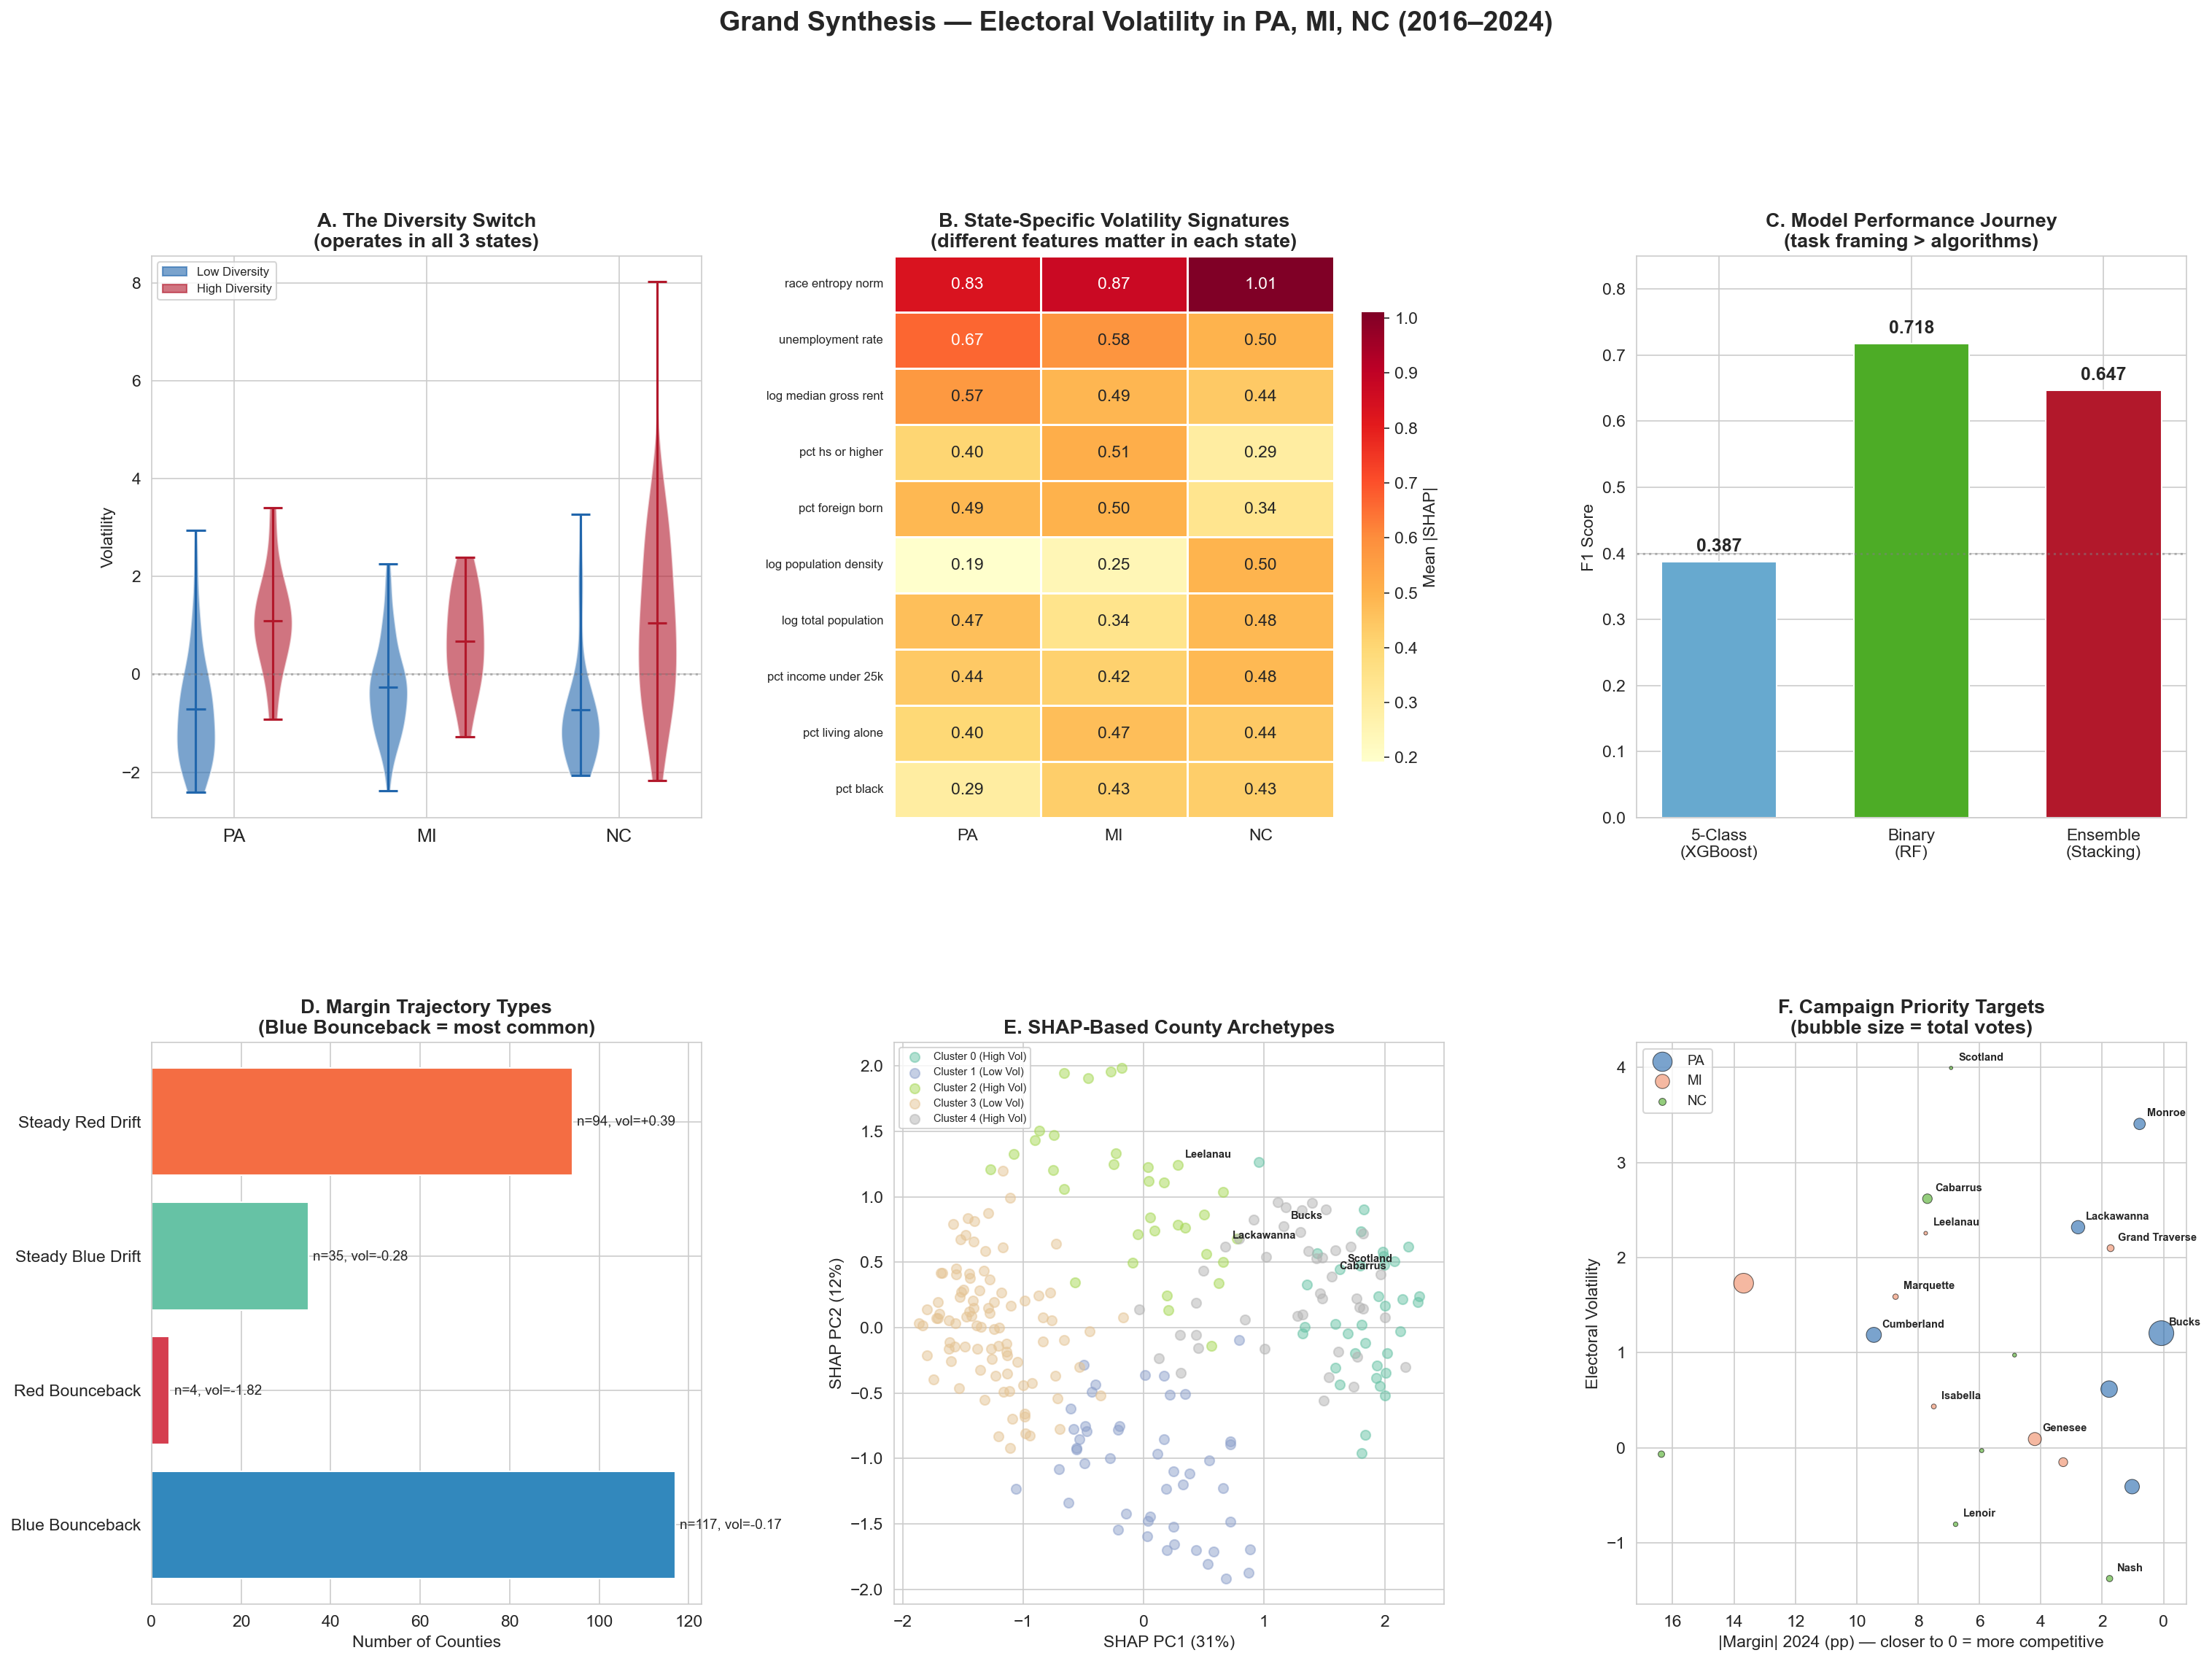

Grand synthesis figure saved.


In [4]:
# ══════════════════════════════════════════════════════════════════
# GRAND SYNTHESIS FIGURE — The Complete Story in 6 Panels
# ══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(24, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ═══ Panel A: The Diversity Switch (violin by state) ═══
ax_a = fig.add_subplot(gs[0, 0])

synth_df = df.merge(entropy_raw, on='county_fips', how='left')
synth_df['div_group'] = np.where(synth_df['entropy_raw'] >= optimal_t,
                                  'High\nDiversity', 'Low\nDiversity')

for i, state in enumerate(['PA', 'MI', 'NC']):
    state_data = synth_df[synth_df['state'] == state]
    for j, group in enumerate(['Low\nDiversity', 'High\nDiversity']):
        data = state_data[state_data['div_group'] == group]['vol_z_abs_sum']
        if len(data) == 0:
            continue
        pos = i * 2.5 + j
        vp = ax_a.violinplot(data, positions=[pos], showmeans=True, showmedians=False)
        color = '#2166ac' if j == 0 else '#b2182b'
        for pc in vp['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.6)
        for partname in ['cbars', 'cmins', 'cmaxes', 'cmeans']:
            vp[partname].set_color(color)

ax_a.set_xticks([0.5, 3, 5.5])
ax_a.set_xticklabels(['PA', 'MI', 'NC'], fontsize=12)
ax_a.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax_a.set_ylabel('Volatility')
ax_a.set_title('A. The Diversity Switch\n(operates in all 3 states)',
               fontsize=13, fontweight='bold')
legend_a = [mpatches.Patch(color='#2166ac', alpha=0.6, label='Low Diversity'),
            mpatches.Patch(color='#b2182b', alpha=0.6, label='High Diversity')]
ax_a.legend(handles=legend_a, fontsize=8, loc='upper left')

# ═══ Panel B: State-Specific Signatures (heatmap) ═══
ax_b = fig.add_subplot(gs[0, 1])

state_importance = {}
for state in ['PA', 'MI', 'NC']:
    mask = df['state'].values == state
    state_shap = np.abs(shap_matrix[mask]).mean(axis=0)
    state_importance[state] = state_shap

imp_matrix = pd.DataFrame(state_importance, index=feature_names)
top10 = imp_matrix.max(axis=1).nlargest(10).index
heatmap_data = imp_matrix.loc[top10]

sns.heatmap(heatmap_data, ax=ax_b, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'Mean |SHAP|', 'shrink': 0.8})
ax_b.set_yticklabels([f.replace('_', ' ') for f in top10], rotation=0, fontsize=8)
ax_b.set_title('B. State-Specific Volatility Signatures\n(different features matter in each state)',
               fontsize=13, fontweight='bold')

# ═══ Panel C: Model Performance Journey ═══
ax_c = fig.add_subplot(gs[0, 2])

stages = ['5-Class\n(XGBoost)', 'Binary\n(RF)', 'Ensemble\n(Stacking)']
f1_values = [0.387, results['Random Forest']['f1'],
             results['Stacking (LR meta)']['f1']]
bar_colors = ['#67a9cf', '#4dac26', '#b2182b']

bars = ax_c.bar(stages, f1_values, color=bar_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, f1_values):
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax_c.set_ylabel('F1 Score')
ax_c.set_ylim(0, 0.85)
ax_c.axhline(0.4, color='gray', linestyle=':', alpha=0.5)
ax_c.set_title('C. Model Performance Journey\n(task framing > algorithms)',
               fontsize=13, fontweight='bold')

# ═══ Panel D: Trajectory Types ═══
ax_d = fig.add_subplot(gs[1, 0])

traj_counts = traj['trajectory'].value_counts()
traj_vol = traj.groupby('trajectory')['vol_z_abs_sum'].mean()
traj_order = ['Blue Bounceback', 'Red Bounceback', 'Steady Blue Drift', 'Steady Red Drift']
traj_colors_list = [TRAJ_COLORS[t] for t in traj_order]

bars_d = ax_d.barh(traj_order, [traj_counts.get(t, 0) for t in traj_order],
                   color=traj_colors_list, edgecolor='white')
for bar, t in zip(bars_d, traj_order):
    count = traj_counts.get(t, 0)
    vol = traj_vol.get(t, 0)
    ax_d.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'n={count}, vol={vol:+.2f}', va='center', fontsize=9)

ax_d.set_xlabel('Number of Counties')
ax_d.set_title('D. Margin Trajectory Types\n(Blue Bounceback = most common)',
               fontsize=13, fontweight='bold')

# ═══ Panel E: SHAP Archetype Map ═══
ax_e = fig.add_subplot(gs[1, 1])

cluster_cmap = plt.cm.Set2(np.linspace(0, 1, 5))
for c in range(5):
    mask = df['shap_cluster'] == c
    direction = cluster_profiles[c]['direction']
    ax_e.scatter(shap_2d[mask, 0], shap_2d[mask, 1],
               c=[cluster_cmap[c]], s=40, alpha=0.5,
               label=f'Cluster {c} ({direction})')

top5 = df.nlargest(5, 'priority_score')
for _, row in top5.iterrows():
    idx = df.index.get_loc(row.name)
    short = row['county_name'].replace(' County', '')
    ax_e.annotate(short, (shap_2d[idx, 0], shap_2d[idx, 1]),
                 fontsize=7, fontweight='bold',
                 xytext=(5, 5), textcoords='offset points')

ax_e.legend(fontsize=7, loc='upper left')
ax_e.set_xlabel(f'SHAP PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)')
ax_e.set_ylabel(f'SHAP PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
ax_e.set_title('E. SHAP-Based County Archetypes',
               fontsize=13, fontweight='bold')

# ═══ Panel F: Campaign Actionability (bubble chart) — FIXED ═══
ax_f = fig.add_subplot(gs[1, 2])

top20 = df.nlargest(20, 'priority_score')

# Get proper margins from traj (which has margin_2024 in pp)
top20_with_margin = top20.merge(
    traj[['county_fips', 'margin_2024']], on='county_fips', how='left'
)

# Get total_votes from master 2024
votes_2024 = master[master['election_year'] == 2024][['county_fips', 'total_votes']].copy()
top20_with_margin = top20_with_margin.merge(votes_2024, on='county_fips', how='left')

for state in ['PA', 'MI', 'NC']:
    mask = top20_with_margin['state'] == state
    if mask.sum() == 0:
        continue
    s_data = top20_with_margin[mask]
    sizes = s_data['total_votes'].fillna(50000) / 3000
    
    ax_f.scatter(np.abs(s_data['margin_2024']),
                s_data['vol_z_abs_sum'],
                s=sizes, c=STATE_COLORS[state], alpha=0.6,
                edgecolors='black', linewidth=0.5, label=state)
    
    # Label top priority counties
    for _, row in s_data.iterrows():
        if row['priority_score'] > df['priority_score'].quantile(0.95):
            short = row['county_name'].replace(' County', '')
            ax_f.annotate(short, (abs(row['margin_2024']), row['vol_z_abs_sum']),
                         fontsize=7, fontweight='bold',
                         xytext=(5, 5), textcoords='offset points')

ax_f.set_xlabel('|Margin| 2024 (pp) — closer to 0 = more competitive')
ax_f.set_ylabel('Electoral Volatility')
ax_f.set_title('F. Campaign Priority Targets\n(bubble size = total votes)',
               fontsize=13, fontweight='bold')
ax_f.legend(fontsize=9)
ax_f.invert_xaxis()

fig.suptitle('Grand Synthesis — Electoral Volatility in PA, MI, NC (2016–2024)',
             fontsize=18, fontweight='bold', y=1.02)
plt.savefig(f'{FIG_DIR}/deepdive2_grand_synthesis.png', dpi=200, bbox_inches='tight')
plt.show()
print('Grand synthesis figure saved.')